In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'D:\Data Analytics\tech_layoffs_hiring_trends\datasets\clean_dataset.csv')
df.head(5)

,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,ai_automation_impact,ai_replacement_risk,open_roles,hiring_trend,remote_jobs_percentage,top_hiring_role,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,6.4,5.0,5426,Moderate Hiring,46.7,ML Engineer,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,0.9,1.1,9666,Moderate Hiring,58.9,ML Engineer,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,7.1,3.9,437,Hiring Freeze,85.4,Frontend Developer,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,10.4,7.4,1075,Hiring Freeze,44.0,Frontend Developer,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,11.4,10.0,537,Moderate Hiring,53.2,Frontend Developer,9.3,6.7,5.8,Bull Market


In [70]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,12000.0,2024.998750,0.817703,2024.0,2024.0,2025.0,2026.00,2026.0
layoffs_count,12000.0,5009.572083,5159.360491,0.0,1369.5,2733.0,6490.00,19999.0
layoff_percentage,12000.0,12.780125,10.212612,0.0,5.1,9.4,17.30,40.0
ai_automation_impact,12000.0,6.376983,3.544012,0.6,3.5,5.9,8.80,16.8
ai_replacement_risk,12000.0,7.208758,2.677148,1.0,5.1,7.6,10.00,10.0
open_roles,12000.0,2884.395000,2149.615907,52.0,1151.0,2282.0,4432.25,9997.0
remote_jobs_percentage,12000.0,50.205150,23.299575,10.0,29.8,50.5,70.70,90.0
ai_adoption_level,12000.0,5.538750,2.583047,1.0,3.3,5.6,7.70,10.0
employee_sentiment,12000.0,6.496217,1.582356,1.3,5.4,6.5,7.60,10.0
job_security_score,12000.0,5.805033,1.649677,1.0,4.7,5.9,7.00,10.0


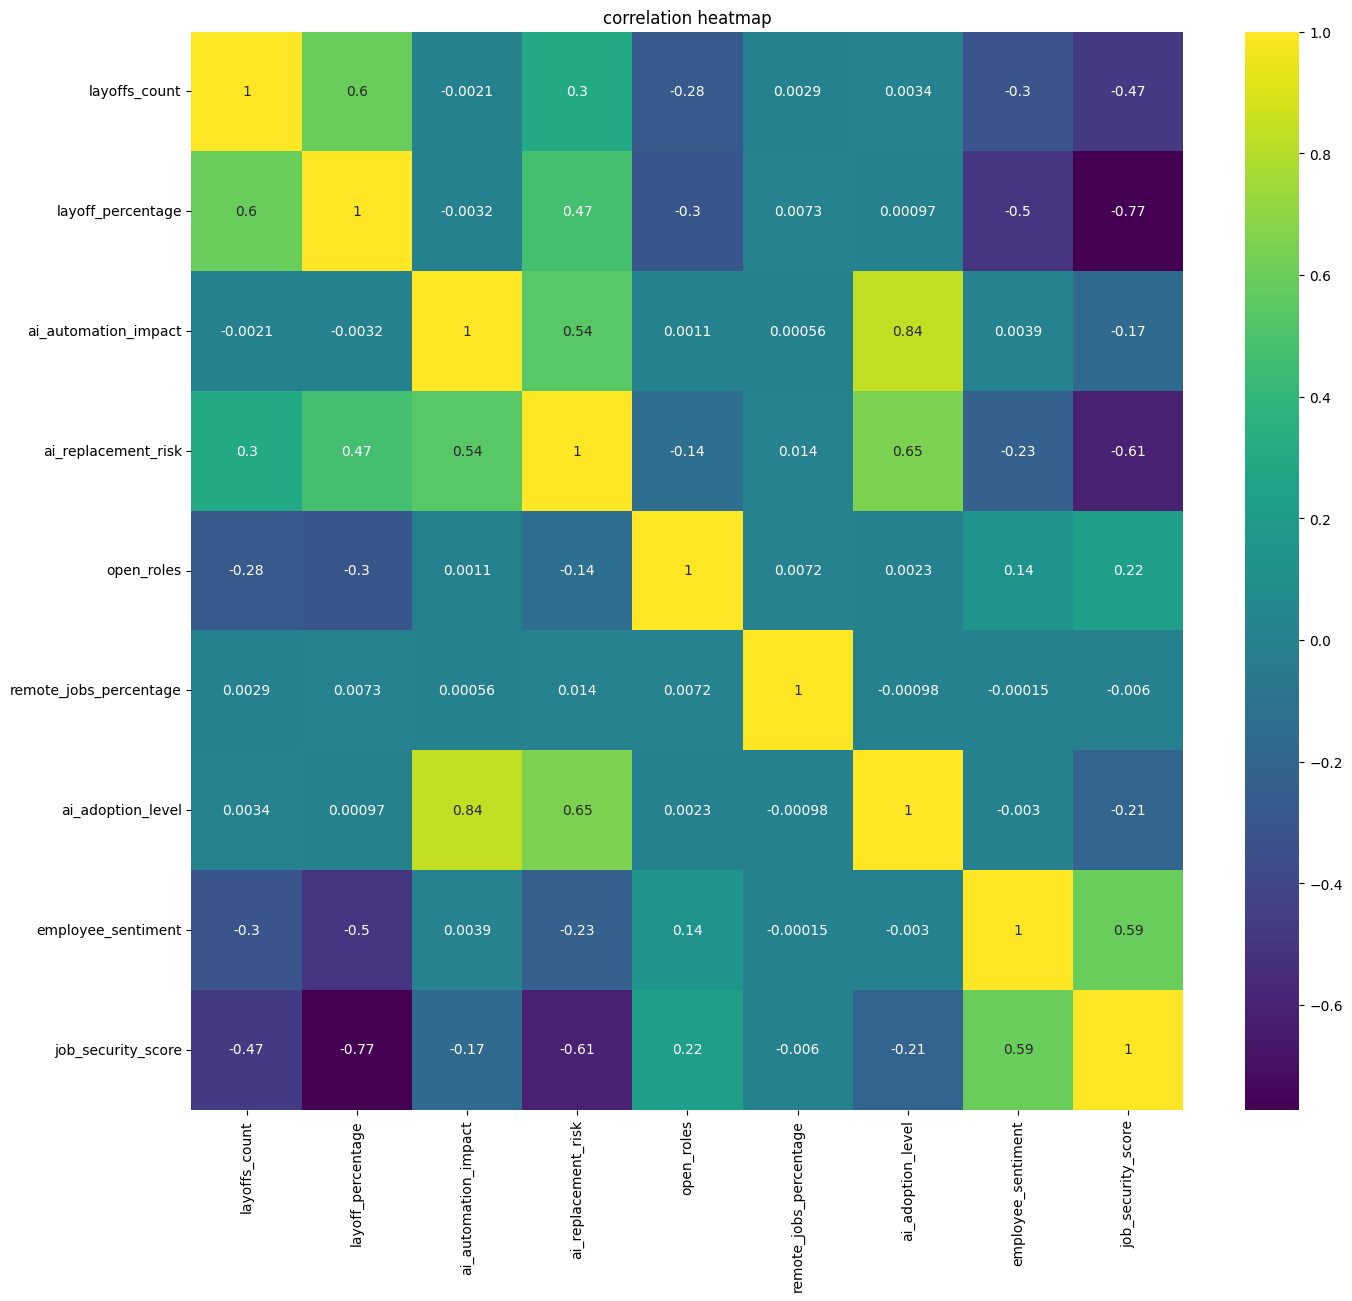

In [71]:
drop_col = df.drop(columns=['year' , 'record_id'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlation heatmap")
plt.show()

1. AI adoption strongly drives replacement risk

AI Adoption Level has a very high positive correlation with AI Automation Impact (0.84) and AI Replacement Risk (0.65).

2. Layoffs sharply reduce job security and employee sentiment

3. Layoff Percentage has a strong negative correlation with Job Security Score (–0.77) and Employee Sentiment (–0.5). Layoffs Count also shows moderate negative links with both.

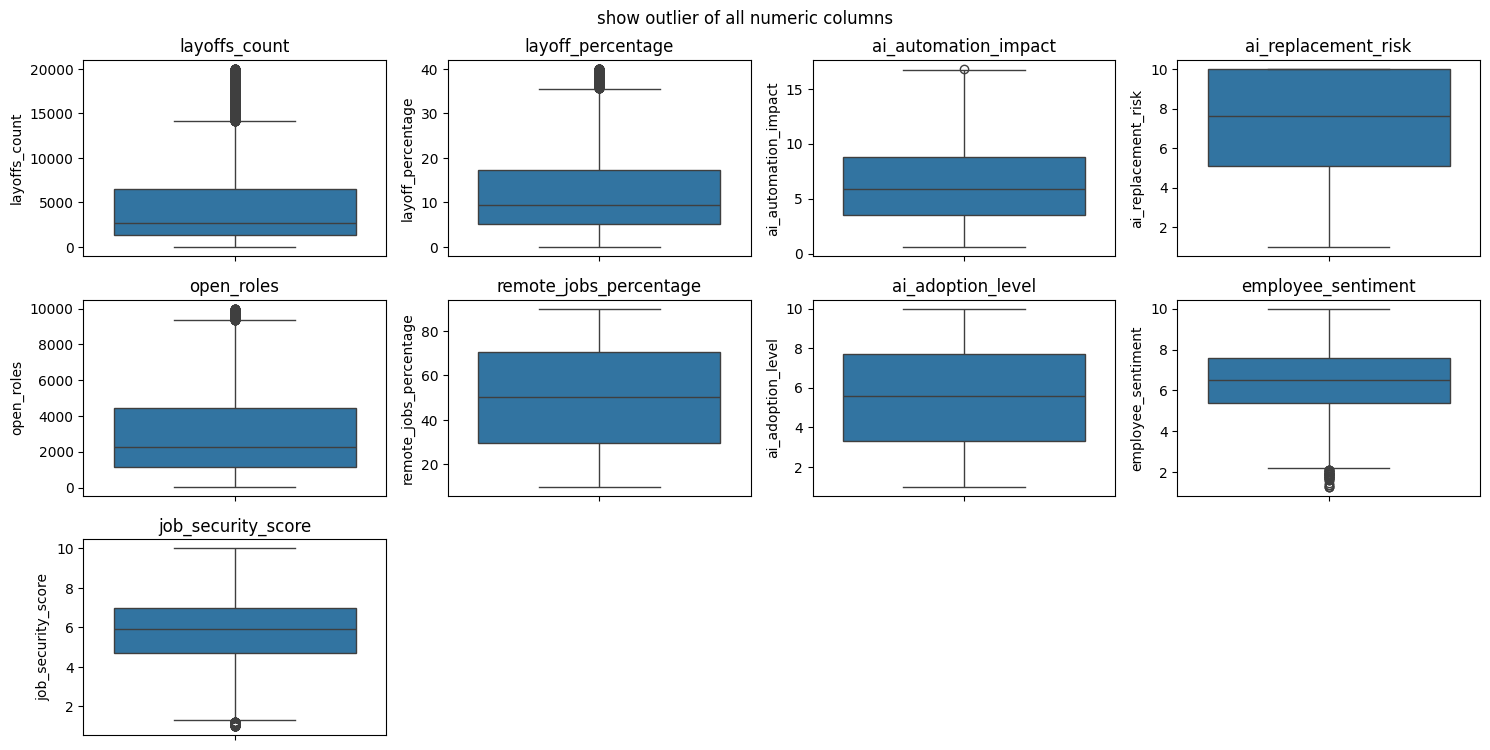

In [72]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.boxplot(df[col])
    plt.title(col)
plt.suptitle('show outlier of all numeric columns')
plt.tight_layout()
plt.show()

In [73]:
# how many outlier in column??
def detect_outliers(df , col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower_bound) | (df[col] > upper_bound))
    print(f"IQR method identified {outliers_iqr.sum()} outliers in {col}")
    return outliers_iqr

outlier_col = ['layoffs_count' , 'layoff_percentage' , 'ai_automation_impact','open_roles','employee_sentiment','job_security_score']

for col in outlier_col:
    detect_outliers(df ,col)

IQR method identified 1194 outliers in layoffs_count
IQR method identified 564 outliers in layoff_percentage
IQR method identified 1 outliers in ai_automation_impact
IQR method identified 113 outliers in open_roles
IQR method identified 38 outliers in employee_sentiment
IQR method identified 43 outliers in job_security_score


# 📊 analysis

In [74]:
# 1 . kpi
overall_layoffs = df['layoffs_count'].sum()
print(f"Overall layoffs: {overall_layoffs}")

overall_layoff_pct = df['layoff_percentage'].mean()
print(f'overall layoff pct {overall_layoff_pct.round(2)} %')

avg_job_security_score = df['job_security_score'].mean()
print(f'avg_job_securiry_score {avg_job_security_score.round(2)}')

total_company = df['company_name'].nunique()
print(f'total company {total_company}')

Overall layoffs: 60114865
overall layoff pct 12.78 %
avg_job_securiry_score 5.81
total company 20


**yerly layoff count and layoff percentage**

,total_layoff,avg_layoff_pct
year,,
2024,20307870,12.79
2025,19761032,12.88
2026,20045963,12.68


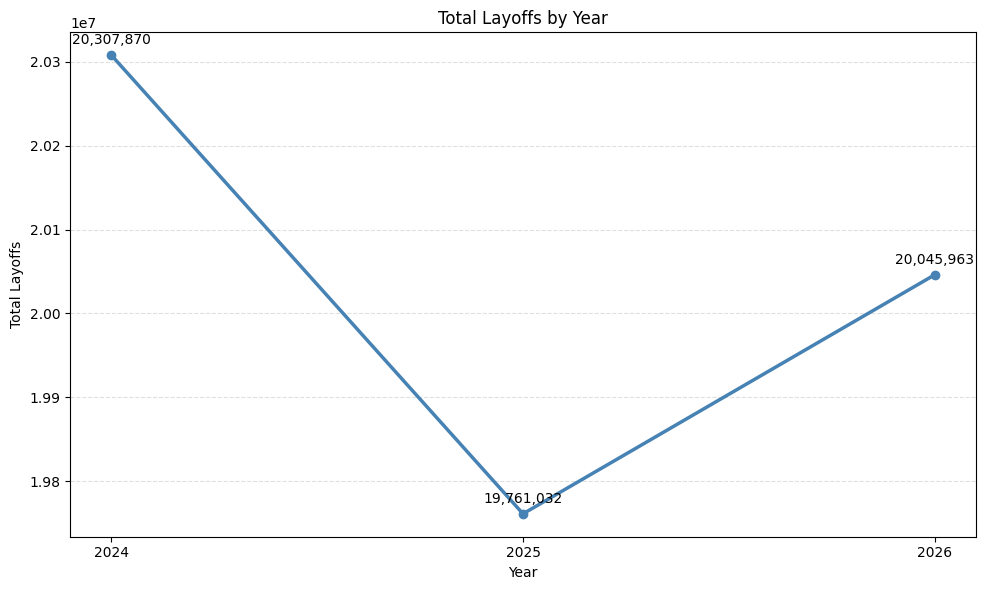

In [36]:
yearly_layoff = df.groupby('year').agg(
    total_layoff = ('layoffs_count' , 'sum'),
    avg_layoff_pct = ('layoff_percentage', 'mean')
).sort_values(by='year')
display(yearly_layoff.round(2))

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_layoff.index,
    yearly_layoff['total_layoff'],
    marker='o',
    linewidth=2.5,
    color='steelblue'
)

for year, total in yearly_layoff['total_layoff'].items():
    plt.annotate(
        f'{total:,.0f}',
        (year, total),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=10
    )

plt.title('Total Layoffs by Year')
plt.xlabel('Year')
plt.ylabel('Total Layoffs')
plt.xticks(yearly_layoff.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**country wise layoff and remote job pct**

,total_layoff,avg_layoff_pct,remote_jobs_pct
country,,,
UK,10629082,13.34,50.02
Singapore,10078642,12.53,49.91
USA,10042659,12.62,49.38
Canada,9942815,12.73,50.50
India,9763402,12.72,50.72
Germany,9658265,12.74,50.73


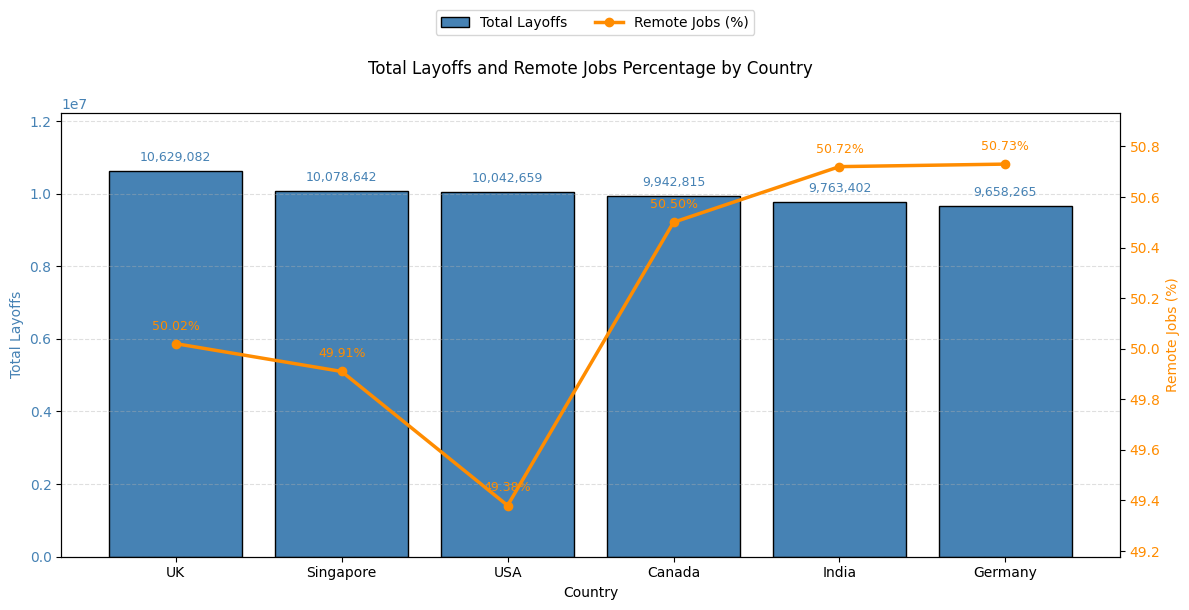

In [62]:
country_layoff = df.groupby('country').agg(
    total_layoff = ('layoffs_count' , 'sum') , 
    avg_layoff_pct = ('layoff_percentage' , 'mean') , 
    remote_jobs_pct = ('remote_jobs_percentage' , 'mean')
).round(2)
display(country_layoff.sort_values(by='total_layoff' , ascending=False))

country_layoff_sorted = country_layoff.sort_values(
    by='total_layoff',
    ascending=False
)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(
    country_layoff_sorted.index,
    country_layoff_sorted['total_layoff'],
    color='steelblue',
    edgecolor='black',
    label='Total Layoffs'
)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{height:,.0f}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 5),
        ha='center',
        va='bottom',
        fontsize=9,
        color='steelblue'
    )

ax1.set_xlabel('Country')
ax1.set_ylabel('Total Layoffs', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.margins(y=0.15)

ax2 = ax1.twinx()
remote_line = ax2.plot(
    country_layoff_sorted.index,
    country_layoff_sorted['remote_jobs_pct'],
    color='darkorange',
    marker='o',
    linewidth=2.5,
    label='Remote Jobs (%)'
)

for country, remote_pct in country_layoff_sorted['remote_jobs_pct'].items():
    ax2.annotate(
        f'{remote_pct:.2f}%',
        (country, remote_pct),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        va='bottom',
        fontsize=9,
        color='darkorange'
    )

ax2.set_ylabel('Remote Jobs (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.margins(y=0.15)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.title('Total Layoffs and Remote Jobs Percentage by Country', pad=28)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**company layoff and remote job pct**

,total_layoff,avg_layoff_pct,remote_jobs_pct
company_name,,,
Databricks,3336757,13.35,48.81
Google,3305744,12.56,49.82
Meta,3180647,12.91,48.71
Spotify,3148320,12.68,48.99
OpenAI,3099179,13.21,50.05
NVIDIA,3030630,12.52,48.99
Salesforce,3020614,12.56,51.34
Netflix,3012687,12.78,51.45
Oracle,3004419,12.89,51.25


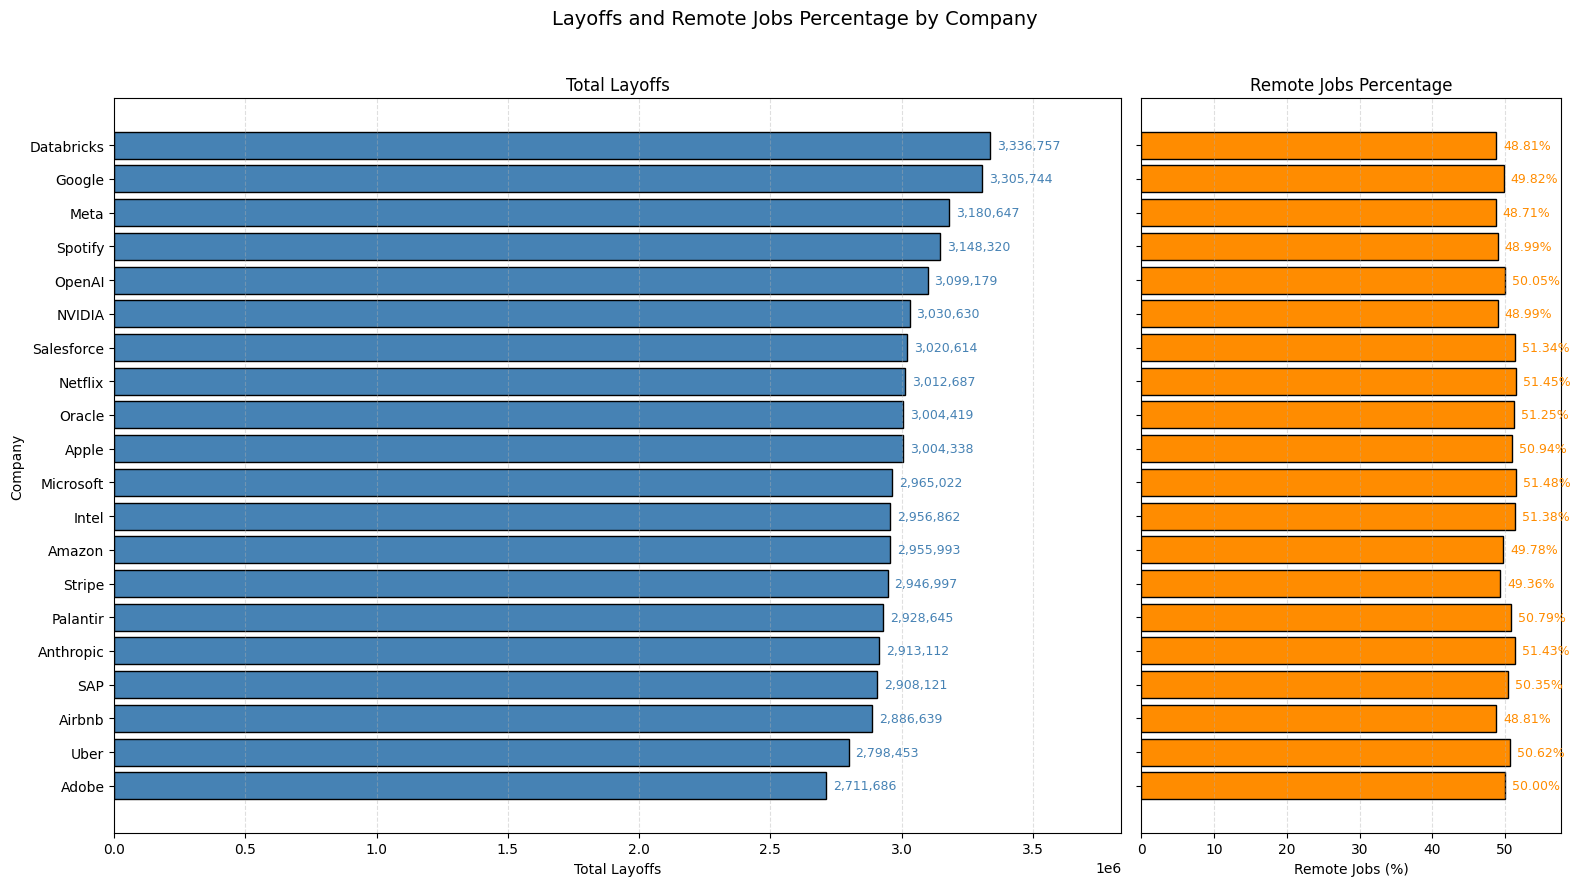

In [65]:
company_layoff = df.groupby('company_name').agg(
    total_layoff = ('layoffs_count' , 'sum'),
    avg_layoff_pct = ('layoff_percentage' , 'mean') , 
    remote_jobs_pct = ('remote_jobs_percentage' , 'mean')
).sort_values(by='total_layoff' , ascending=False)
display(company_layoff.round(2))

company_layoff_sorted = company_layoff.sort_values(
    by='total_layoff',
    ascending=True
)

positions = np.arange(len(company_layoff_sorted))
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 9),
    sharey=True,
    gridspec_kw={'width_ratios': [2.4, 1]}
)

layoff_bars = ax1.barh(
    positions,
    company_layoff_sorted['total_layoff'],
    color='steelblue',
    edgecolor='black'
)

for bar in layoff_bars:
    width = bar.get_width()
    ax1.annotate(
        f'{width:,.0f}',
        (width, bar.get_y() + bar.get_height() / 2),
        textcoords='offset points',
        xytext=(5, 0),
        ha='left',
        va='center',
        fontsize=9,
        color='steelblue'
    )

ax1.set_yticks(positions)
ax1.set_yticklabels(company_layoff_sorted.index)
ax1.set_xlabel('Total Layoffs')
ax1.set_ylabel('Company')
ax1.grid(axis='x', linestyle='--', alpha=0.4)
ax1.set_title('Total Layoffs')
ax1.set_xlim(0, company_layoff_sorted['total_layoff'].max() * 1.15)

remote_bars = ax2.barh(
    positions,
    company_layoff_sorted['remote_jobs_pct'],
    color='darkorange',
    edgecolor='black'
)

for bar in remote_bars:
    width = bar.get_width()
    ax2.annotate(
        f'{width:.2f}%',
        (width, bar.get_y() + bar.get_height() / 2),
        textcoords='offset points',
        xytext=(5, 0),
        ha='left',
        va='center',
        fontsize=9,
        color='darkorange'
    )

ax2.set_xlabel('Remote Jobs (%)')
ax2.set_title('Remote Jobs Percentage')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
ax2.set_xlim(0, company_layoff_sorted['remote_jobs_pct'].max() * 1.12)

fig.suptitle('Layoffs and Remote Jobs Percentage by Company', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**industry layoff and remote job pct**

,total_layoff,avg_layoff_pct,remote_jobs_pct
industry,,,
Social Media,9012817,13.16,50.00
AI,8751526,12.76,50.55
E-Commerce,8618351,12.97,50.15
Cybersecurity,8569627,12.89,49.69
Gaming,8552964,12.39,50.06
FinTech,8406741,12.48,50.66
Cloud,8202839,12.80,50.34


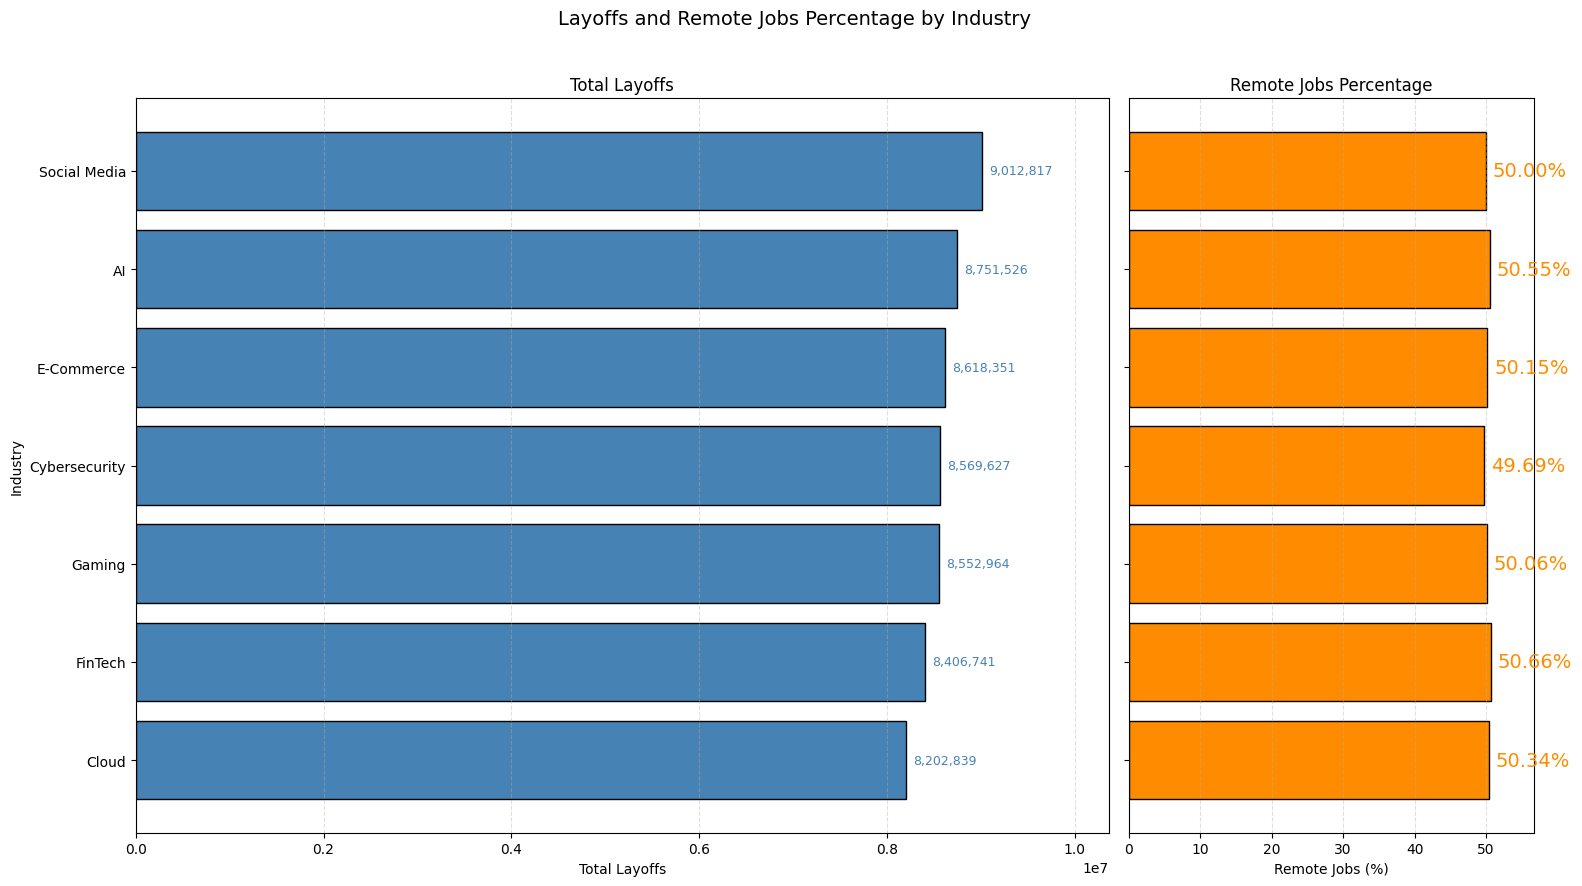

In [68]:
industry_layoff = df.groupby('industry').agg(
    total_layoff = ('layoffs_count' , 'sum'),
    avg_layoff_pct = ('layoff_percentage' , 'mean') , 
    remote_jobs_pct = ('remote_jobs_percentage' , 'mean')
).sort_values(by='total_layoff' , ascending=False)
display(industry_layoff.round(2))

industry_layoff_sorted = industry_layoff.sort_values(
    by='total_layoff',
    ascending=True
)

positions = np.arange(len(industry_layoff_sorted))
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 9),
    sharey=True,
    gridspec_kw={'width_ratios': [2.4, 1]}
)

layoff_bars = ax1.barh(
    positions,
    industry_layoff_sorted['total_layoff'],
    color='steelblue',
    edgecolor='black'
)

for bar in layoff_bars:
    width = bar.get_width()
    ax1.annotate(
        f'{width:,.0f}',
        (width, bar.get_y() + bar.get_height() / 2),
        textcoords='offset points',
        xytext=(5, 0),
        ha='left',
        va='center',
        fontsize=9,
        color='steelblue'
    )

ax1.set_yticks(positions)
ax1.set_yticklabels(industry_layoff_sorted.index)
ax1.set_xlabel('Total Layoffs')
ax1.set_ylabel('Industry')
ax1.grid(axis='x', linestyle='--', alpha=0.4)
ax1.set_title('Total Layoffs')
ax1.set_xlim(0, industry_layoff_sorted['total_layoff'].max() * 1.15)

remote_bars = ax2.barh(
    positions,
    industry_layoff_sorted['remote_jobs_pct'],
    color='darkorange',
    edgecolor='black'
)

for bar in remote_bars:
    width = bar.get_width()
    ax2.annotate(
        f'{width:.2f}%',
        (width, bar.get_y() + bar.get_height() / 2),
        textcoords='offset points',
        xytext=(5, 0),
        ha='left',
        va='center',
        fontsize=14,
        color='darkorange'
    )

ax2.set_xlabel('Remote Jobs (%)')
ax2.set_title('Remote Jobs Percentage')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
ax2.set_xlim(0, industry_layoff_sorted['remote_jobs_pct'].max() * 1.12)

fig.suptitle('Layoffs and Remote Jobs Percentage by Industry', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**company size layoff**

,total_layoff,avg_layoff_pct
company_size,,
Big Tech,15182981,12.51
Enterprise,15013363,12.89
Startup,15005277,12.97
Mid-size,14913244,12.77


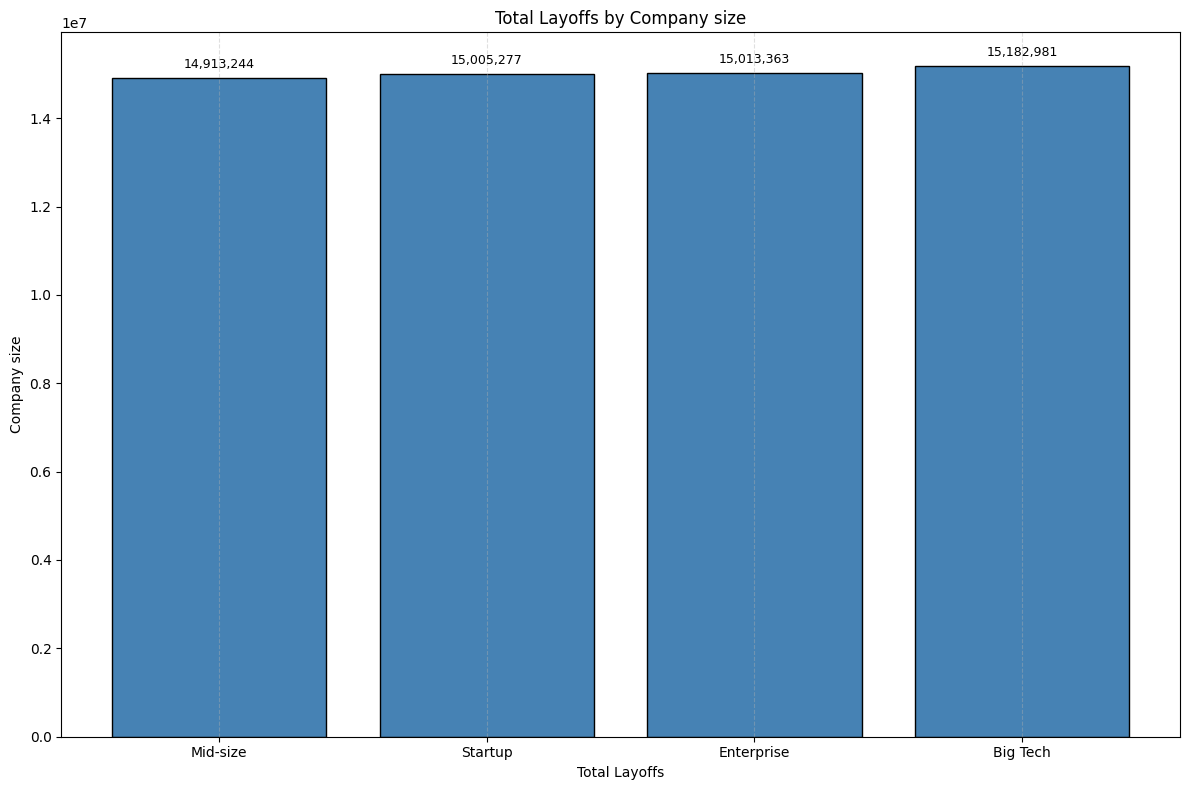

In [52]:
companysize_layoff = df.groupby('company_size').agg(
    total_layoff = ('layoffs_count' , 'sum'),
    avg_layoff_pct = ('layoff_percentage' , 'mean')
).sort_values(by='total_layoff' , ascending=False)
display(companysize_layoff.round(2))

companysize_layoff_sorted = companysize_layoff.sort_values(
    by='total_layoff',
    ascending=True
)

plt.figure(figsize=(12, 8))

bars = plt.bar(
    companysize_layoff_sorted.index,
    companysize_layoff_sorted['total_layoff'],
    color='steelblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:,.0f}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 5),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Layoffs by Company size')
plt.xlabel('Total Layoffs')
plt.ylabel('Company size')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**reason for layoff**

,total_layoff,avg_layoff
reason_for_layoffs,,
AI Automation,12411961,5097.31
Restructuring,12399103,5164.14
Cost Cutting,11974006,4995.41
Market Slowdown,11754937,5036.39
Overhiring Correction,11574858,4757.44


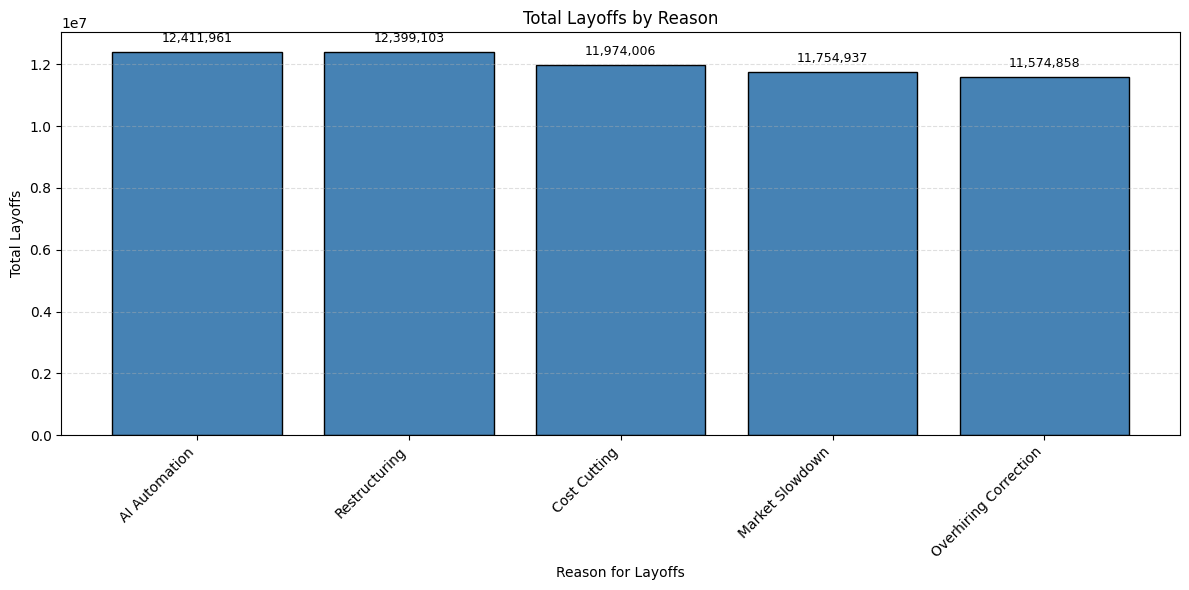

In [57]:
layoff_reason = df.groupby('reason_for_layoffs').agg(
    total_layoff = ('layoffs_count' , 'sum') , 
    avg_layoff = ('layoffs_count' , 'mean')
).sort_values(by='total_layoff' , ascending=False)
display(layoff_reason.round(2))

plt.figure(figsize=(12, 6))

bars = plt.bar(
    layoff_reason.index,
    layoff_reason['total_layoff'],
    color='steelblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:,.0f}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 5),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Layoffs by Reason')
plt.xlabel('Reason for Layoffs')
plt.ylabel('Total Layoffs')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**hiring trend analysis moderate vs aggresive**

,avg_open_role
hiring_trend,
Aggressive Hiring,6554.71
Moderate Hiring,3962.00


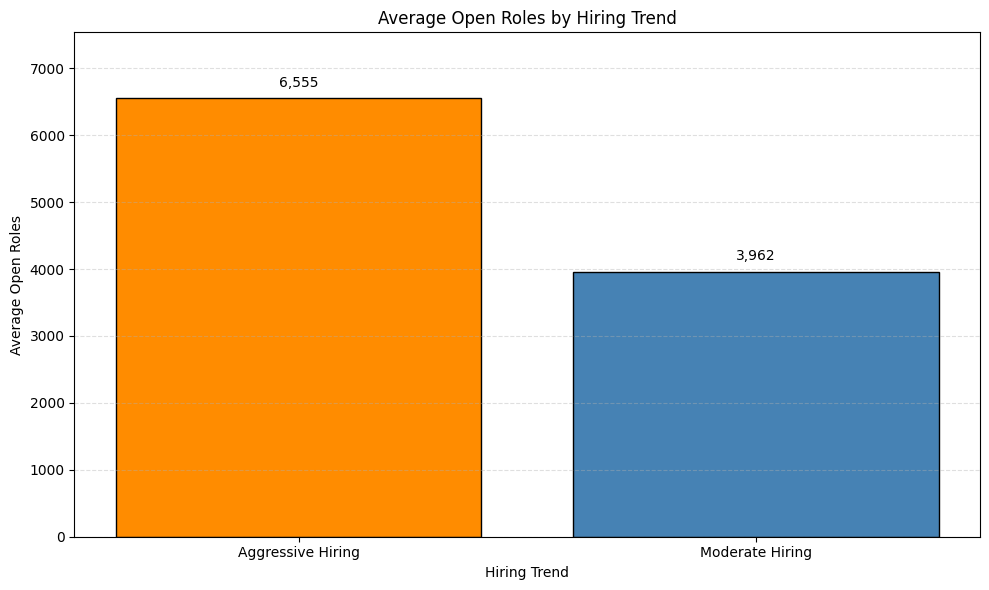

In [84]:
hiring_trend = (
    df[df['hiring_trend'].isin(['Moderate Hiring', 'Aggressive Hiring'])]
    .groupby('hiring_trend')
    .agg(
        avg_open_role = ('open_roles' , 'mean') , 
    )
    .sort_values(by='avg_open_role', ascending=False)
)

display(hiring_trend.round(2))

plt.figure(figsize=(10, 6))

bars = plt.bar(
    hiring_trend.index,
    hiring_trend['avg_open_role'],
    color=['darkorange', 'steelblue'],
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:,.0f}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Average Open Roles by Hiring Trend')
plt.xlabel('Hiring Trend')
plt.ylabel('Average Open Roles')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.margins(y=0.15)
plt.tight_layout()
plt.show()

**top hiring role**

,total_open_role,jo_security_score,ai_replacement_risk
top_hiring_role,,,
ML Engineer,8019525,5.87,7.12
Data Scientist,7751137,5.75,7.34
Frontend Developer,3247202,5.76,7.33
DevOps Engineer,3242507,5.84,7.13
Cloud Engineer,3223586,5.85,7.19
Software Engineer,3177275,5.81,7.13
Product Manager,2993558,5.79,7.26
Cybersecurity Analyst,2957950,5.77,7.14


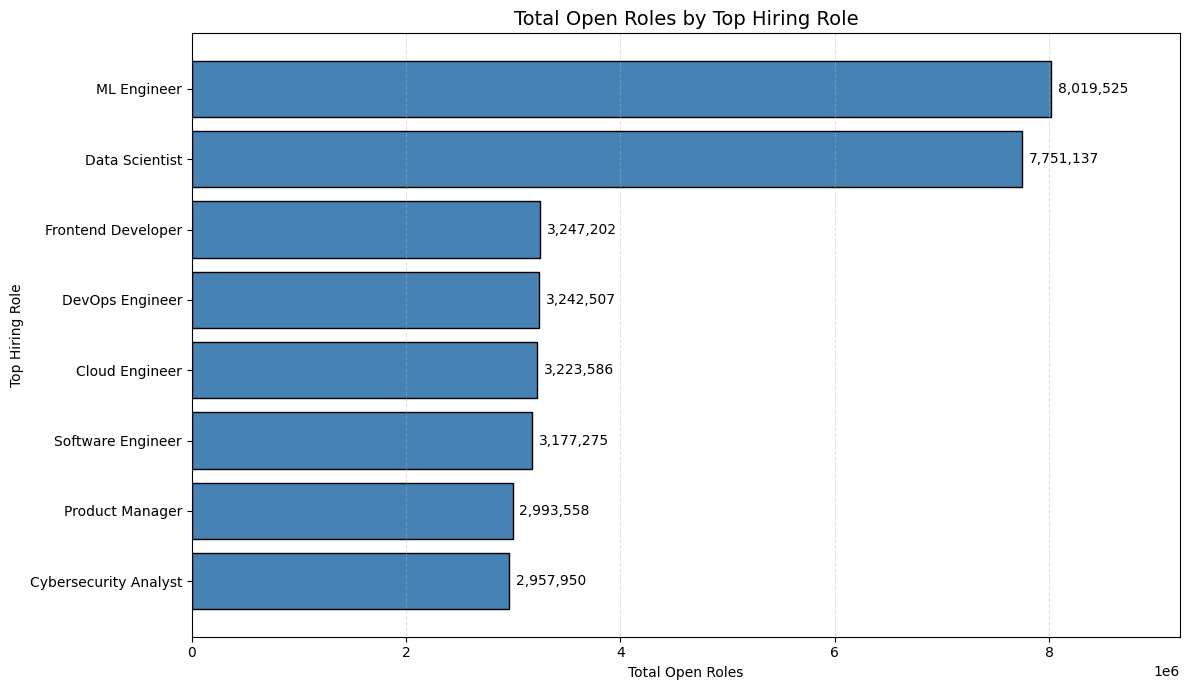

In [8]:
hiring_role = df.groupby('top_hiring_role').agg(
    total_open_role = ('open_roles' , 'sum'),
    jo_security_score = ('job_security_score' , 'mean') , 
    ai_replacement_risk = ('ai_replacement_risk' , 'mean')
).sort_values(by='total_open_role' , ascending=False)
display(hiring_role.round(2))

plot_data = hiring_role.sort_values('total_open_role', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_data.index,
    plot_data['total_open_role'],
    color='steelblue',
    edgecolor='black'
)

ax.bar_label(
    bars,
    labels=[f'{value:,.0f}' for value in plot_data['total_open_role']],
    padding=5,
    fontsize=10
)

ax.set_title('Total Open Roles by Top Hiring Role', fontsize=14)
ax.set_xlabel('Total Open Roles')
ax.set_ylabel('Top Hiring Role')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, plot_data['total_open_role'].max() * 1.15)

plt.tight_layout()
plt.show()

**market condition vs hiring trend**

hiring_trend,Aggressive Hiring,Moderate Hiring
market_condition,,
Bull Market,1922388,9023746
Recession,290926,1663706
Stable,1214801,8266763


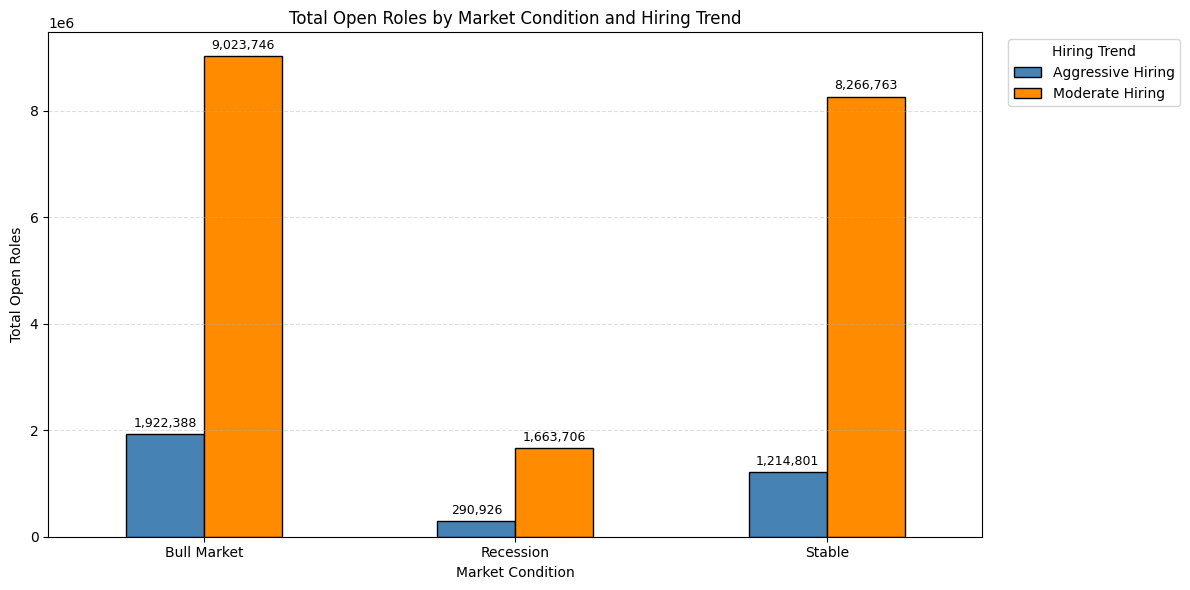

In [93]:
market_condition_hiring_trend = (
    df[df['hiring_trend'].isin(['Aggressive Hiring', 'Moderate Hiring'])]
    .pivot_table(
        index='market_condition',
        columns='hiring_trend',
        values='open_roles',
        aggfunc='sum',
        fill_value=0
    )
)
display(market_condition_hiring_trend.round(2))

ax = market_condition_hiring_trend.plot(
    kind='bar',
    figsize=(12, 6),
    color=['steelblue', 'darkorange', 'seagreen', 'mediumpurple'],
    edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value:,.0f}' if value > 0 else '' for value in container.datavalues],
        padding=3,
        fontsize=9
    )

ax.set_title('Total Open Roles by Market Condition and Hiring Trend')
ax.set_xlabel('Market Condition')
ax.set_ylabel('Total Open Roles')
ax.legend(title='Hiring Trend', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**layoff by market condition**

,total_layoff,avg_layoff_pct
market_condition,,
Recession,40847207,24.09
Stable,14172713,9.57
Bull Market,5094945,5.05


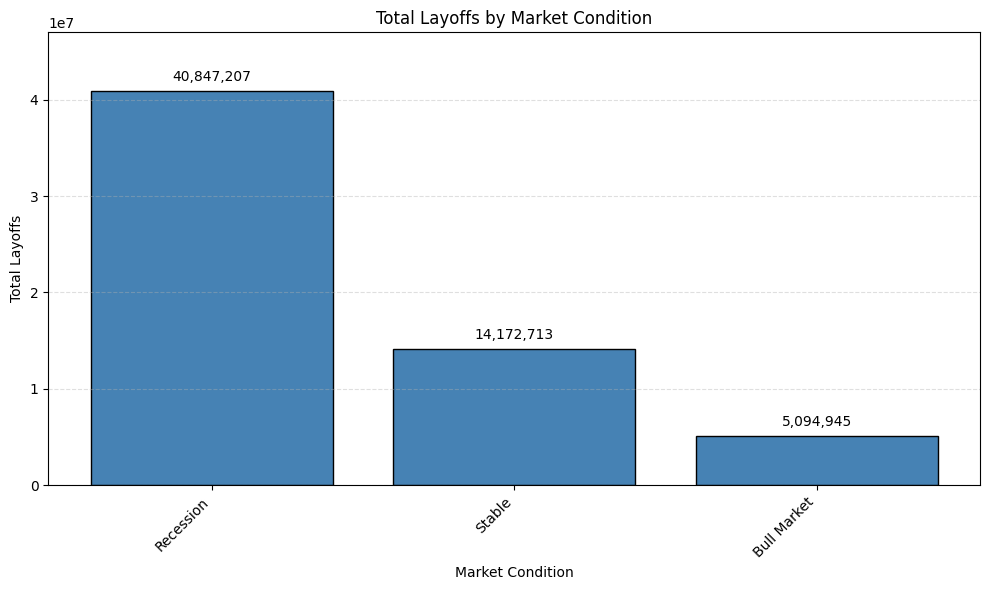

In [9]:
market_layoff = df.groupby('market_condition').agg(
    total_layoff=('layoffs_count','sum'),
    avg_layoff_pct=('layoff_percentage','mean')
).sort_values('total_layoff', ascending=False)
display(market_layoff.round(2))

plt.figure(figsize=(10, 6))

bars = plt.bar(
    market_layoff.index,
    market_layoff['total_layoff'],
    color='steelblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:,.0f}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 5),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Total Layoffs by Market Condition')
plt.xlabel('Market Condition')
plt.ylabel('Total Layoffs')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.margins(y=0.15)
plt.tight_layout()
plt.show()

**Sentiment/job security trend over time**

,avg_sentiment,avg_job_security
year,,
2024,6.50,5.82
2025,6.48,5.81
2026,6.51,5.79


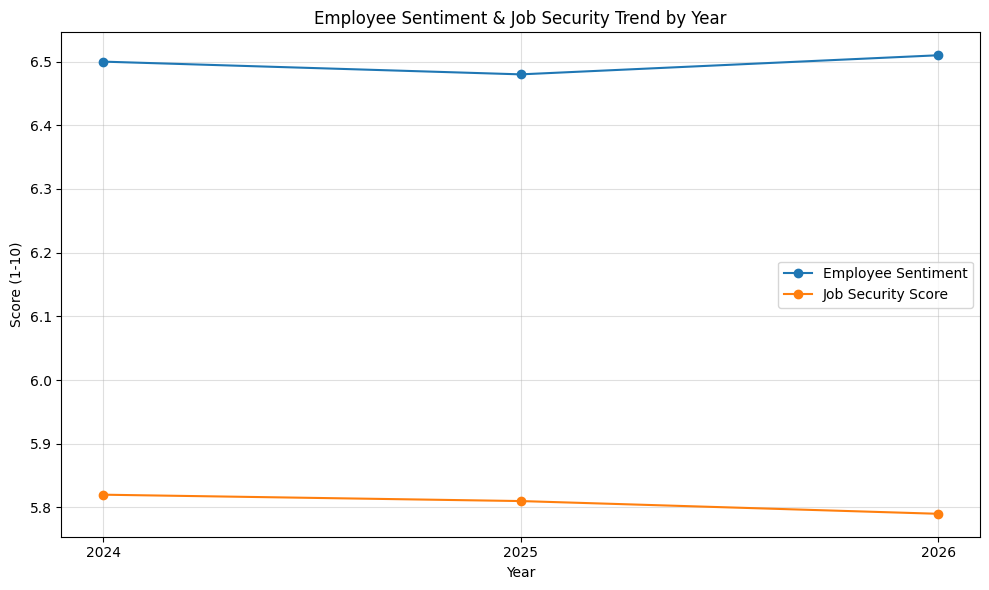

In [ ]:
yearly_sentiment = df.groupby('year').agg(
    avg_sentiment=('employee_sentiment','mean'),
    avg_job_security=('job_security_score','mean')
).round(2)
display(yearly_sentiment)

plt.figure(figsize=(10,6))
plt.plot(yearly_sentiment.index, yearly_sentiment['avg_sentiment'], marker='o', label='Employee Sentiment')
plt.plot(yearly_sentiment.index, yearly_sentiment['avg_job_security'], marker='o', label='Job Security Score')
plt.title('Employee Sentiment & Job Security Trend by Year')
plt.xlabel('Year'); plt.ylabel('Score (1-10)')
plt.legend(); plt.grid(alpha=0.4)
plt.xticks(yearly_sentiment.index)
plt.tight_layout()
plt.show()